# Replica Parameter Uncertainty

Summary notebook for the current `../Fits/replica_refits.csv` schema.
It maps `param_i` columns back to the active card parameter names and reports
robust central intervals for the stored replica refits.


In [1]:
import csv
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
import seaborn as sns

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")


In [ ]:
fit_name = "Final"
replica_results_path = Path("../Fits/replica_data/replica_0325.csv")
pairplot_mode = "free"  # "free" or "all"
use_success_only = False
show_success_failure_overlay = True


In [3]:
card_path = Path("../Cards") / f"{fit_name}.jl"
card_text = card_path.read_text(encoding="utf-8")

struct_match = re.search(r"struct\s+Params_Struct(.*?)end", card_text, re.S)
if struct_match is None:
    raise ValueError(f"Could not find Params_Struct in {card_path}")

param_names = re.findall(
    r"([A-Za-z_][A-Za-z0-9_]*)\s*::\s*Float32",
    struct_match.group(1),
)

def latex_param_name(name):
    special = {
        "logx0": r"$\log x_0$",
        "sigx": r"$\sigma_x$",
        "amp": r"$A$",
        "BNP": r"$B_{\rm NP}$",
    }
    if name in special:
        return special[name]

    match = re.fullmatch(r"([A-Za-z]+)(\d+)", name)
    if match:
        base, idx = match.groups()
        if base == "lambda":
            return rf"$\lambda_{{{idx}}}$"
        return rf"${base}_{{{idx}}}$"

    return rf"${name}$"

latex_param_labels = {name: latex_param_name(name) for name in param_names}
param_columns = [f"param_{i}" for i in range(len(param_names))]

init_matches = re.findall(r"(?ms)^\s*initial_params\s*=\s*\[([^\]]*)\]", card_text)
if not init_matches:
    raise ValueError(f"Could not find initial_params in {card_path}")
initial_params = np.asarray(
    [float(x) for x in re.findall(r"-?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?", init_matches[-1])],
    dtype=float,
)

frozen_match = re.search(r"frozen_indices\s*=\s*\[([^\]]*)\]", card_text)
frozen_idx = (
    np.asarray([int(x) for x in re.findall(r"-?\d+", frozen_match.group(1))], dtype=int)
    if frozen_match
    else np.asarray([], dtype=int)
)
frozen_set = set(frozen_idx.tolist())

param_info_df = pd.DataFrame(
    {
        "index": np.arange(len(param_names), dtype=int),
        "parameter": param_names,
        "latex_label": [latex_param_labels[name] for name in param_names],
        "initial_value": initial_params[: len(param_names)],
        "frozen": [i in frozen_set for i in range(len(param_names))],
    }
)
display(param_info_df)


,index,parameter,latex_label,initial_value,frozen
0,0,lambda1,$\lambda_{1}$,0.023656,False
1,1,lambda2,$\lambda_{2}$,1.054291,False
2,2,lambda3,$\lambda_{3}$,-2.354365,False
3,3,logx0,$\log x_0$,-5.207703,False
4,4,sigx,$\sigma_x$,1.103274,False
5,5,amp,$A$,-0.431106,False
6,6,BNP,$B_{\rm NP}$,1.494665,False
7,7,c0,$c_{0}$,0.070013,False
8,8,c1,$c_{1}$,0.027637,False


In [4]:
def load_replica_results(path):
    expected_columns = [
        "replica_id",
        "pdf_replica_id",
        "success",
        "nfev",
        "best_chi2dN",
        *param_columns,
    ]

    with path.open("r", encoding="utf-8", newline="") as handle:
        rows = list(csv.reader(handle))

    if len(rows) < 2:
        raise ValueError(f"{path} does not contain any replica rows")

    body = []
    for row in rows[1:]:
        if not row or not any(part.strip() for part in row):
            continue
        if len(row) < len(expected_columns):
            raise ValueError(
                f"Replica row has {len(row)} columns; expected at least {len(expected_columns)}"
            )
        body.append(row[: len(expected_columns)])

    df = pd.DataFrame(body, columns=expected_columns)
    for col in expected_columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["replica_id", "best_chi2dN", *param_columns]).copy()
    df["replica_id"] = df["replica_id"].astype(int)
    df["success"] = df["success"].astype("Int64")
    df["nfev"] = df["nfev"].astype("Int64")
    df["pdf_replica_id"] = df["pdf_replica_id"].astype("Int64")

    for col, name in zip(param_columns, param_names):
        df[name] = df[col]

    return df.sort_values("replica_id").reset_index(drop=True)

replica_results_all_df = load_replica_results(replica_results_path)
replica_results_df = replica_results_all_df.copy()
if use_success_only:
    replica_results_df = replica_results_df[replica_results_df["success"] == 1].reset_index(drop=True)
print(f"Loaded {len(replica_results_df)} replica refits from {replica_results_path}")
print(f"use_success_only = {use_success_only}")
print("success counts in source file:")
display(replica_results_all_df["success"].value_counts(dropna=False).sort_index().rename("count").to_frame())
display(replica_results_df.head())


Loaded 100 replica refits from ..\Fits\replica_data\replica_0325.csv
use_success_only = False
success counts in source file:


,count
success,
0,20
1,80


,replica_id,pdf_replica_id,success,nfev,best_chi2dN,param_0,param_1,param_2,param_3,param_4,...,param_8,lambda1,lambda2,lambda3,logx0,sigx,amp,BNP,c0,c1
0,0,1,1,1592,1.775060,-0.031443,1.088764,-2.359929,-5.408433,1.371444,...,0.033293,-0.031443,1.088764,-2.359929,-5.408433,1.371444,-0.682459,1.461688,0.064333,0.033293
1,1,2,1,1582,1.828388,0.014120,1.039218,-2.675658,-5.551660,1.126039,...,0.019571,0.014120,1.039218,-2.675658,-5.551660,1.126039,-0.947766,1.600648,0.072324,0.019571
2,2,3,1,1581,1.995664,0.001420,1.166254,-2.777019,-5.382196,1.220304,...,0.027692,0.001420,1.166254,-2.777019,-5.382196,1.220304,-0.561196,1.547608,0.064439,0.027692
3,3,4,1,1590,1.731992,-0.040958,0.849377,-1.730298,-5.336844,1.127722,...,0.047871,-0.040958,0.849377,-1.730298,-5.336844,1.127722,-0.462254,1.215766,0.072271,0.047871
4,4,5,1,1524,2.054848,0.019749,1.022390,-2.210232,-4.957544,1.125250,...,0.037197,0.019749,1.022390,-2.210232,-4.957544,1.125250,-0.374391,1.385322,0.075136,0.037197


In [5]:
alpha = 0.15865

def summarize_columns(df, columns):
    summary = pd.DataFrame(index=columns)
    summary["mean"] = df[columns].mean()
    summary["std"] = df[columns].std(ddof=1)
    summary["q_lo"] = df[columns].quantile(alpha)
    summary["median"] = df[columns].quantile(0.5)
    summary["q_hi"] = df[columns].quantile(1.0 - alpha)
    summary["minus"] = summary["median"] - summary["q_lo"]
    summary["plus"] = summary["q_hi"] - summary["median"]
    return summary

param_summary = summarize_columns(replica_results_df, param_columns)
param_summary.insert(0, "parameter", param_names)
param_summary.insert(1, "initial_value", initial_params[: len(param_names)])
param_summary.insert(2, "frozen", [i in frozen_set for i in range(len(param_names))])
display(param_summary)

display(replica_results_df[["best_chi2dN", "nfev"]].describe())


,parameter,initial_value,frozen,mean,std,q_lo,median,q_hi,minus,plus
param_0,lambda1,0.023656,False,0.027078,0.053967,-0.024591,0.021823,0.064391,0.046415,0.042567
param_1,lambda2,1.054291,False,1.038237,0.175248,0.859192,1.033168,1.200239,0.173976,0.167071
param_2,lambda3,-2.354365,False,-2.342816,0.447597,-2.719233,-2.332172,-1.882523,0.387061,0.449649
param_3,logx0,-5.207703,False,-5.148347,0.369336,-5.489945,-5.177613,-4.874092,0.312332,0.303522
param_4,sigx,1.103274,False,1.079624,0.162588,0.928298,1.104287,1.240705,0.175990,0.136417
param_5,amp,-0.431106,False,-0.474761,0.208131,-0.596705,-0.447083,-0.321497,0.149622,0.125586
param_6,BNP,1.494665,False,1.528419,0.164538,1.378730,1.521665,1.671648,0.142936,0.149983
param_7,c0,0.070013,False,0.070696,0.006459,0.063862,0.070214,0.076860,0.006352,0.006646
param_8,c1,0.027637,False,0.027478,0.008844,0.019521,0.026841,0.035996,0.007320,0.009155


,best_chi2dN,nfev
count,100.000000,100.0
mean,1.930114,1549.33
std,0.154361,88.431227
min,1.530586,989.0
25%,1.810828,1531.5
50%,1.921832,1569.5
75%,2.023937,1591.25
max,2.438255,1620.0


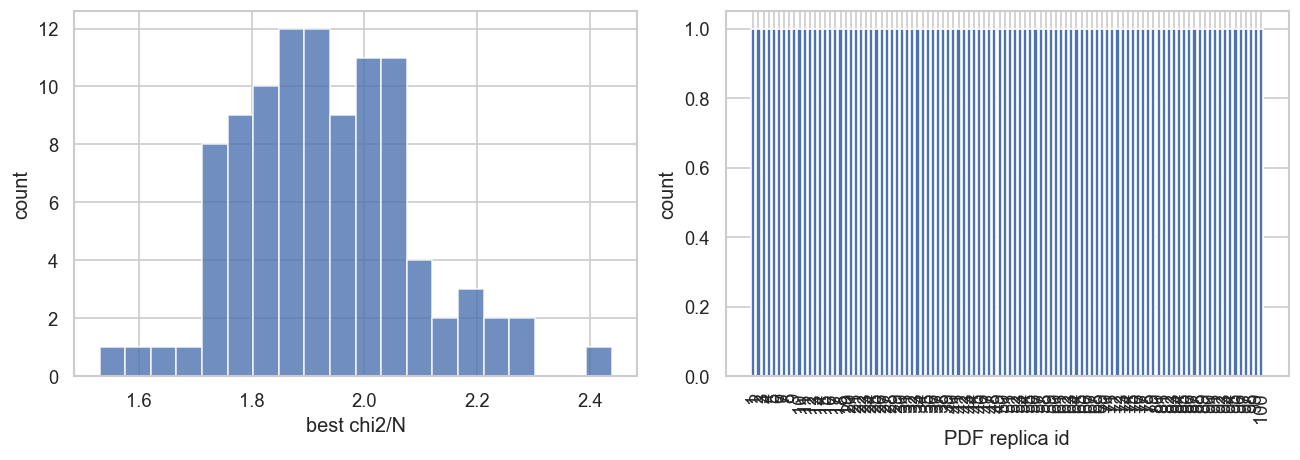

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(replica_results_df["best_chi2dN"], bins=20, alpha=0.8)
axes[0].set_xlabel("best chi2/N")
axes[0].set_ylabel("count")

pdf_counts = replica_results_df["pdf_replica_id"].dropna().astype(int).value_counts().sort_index()
axes[1].bar(pdf_counts.index.astype(str), pdf_counts.values)
axes[1].set_xlabel("PDF replica id")
axes[1].set_ylabel("count")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


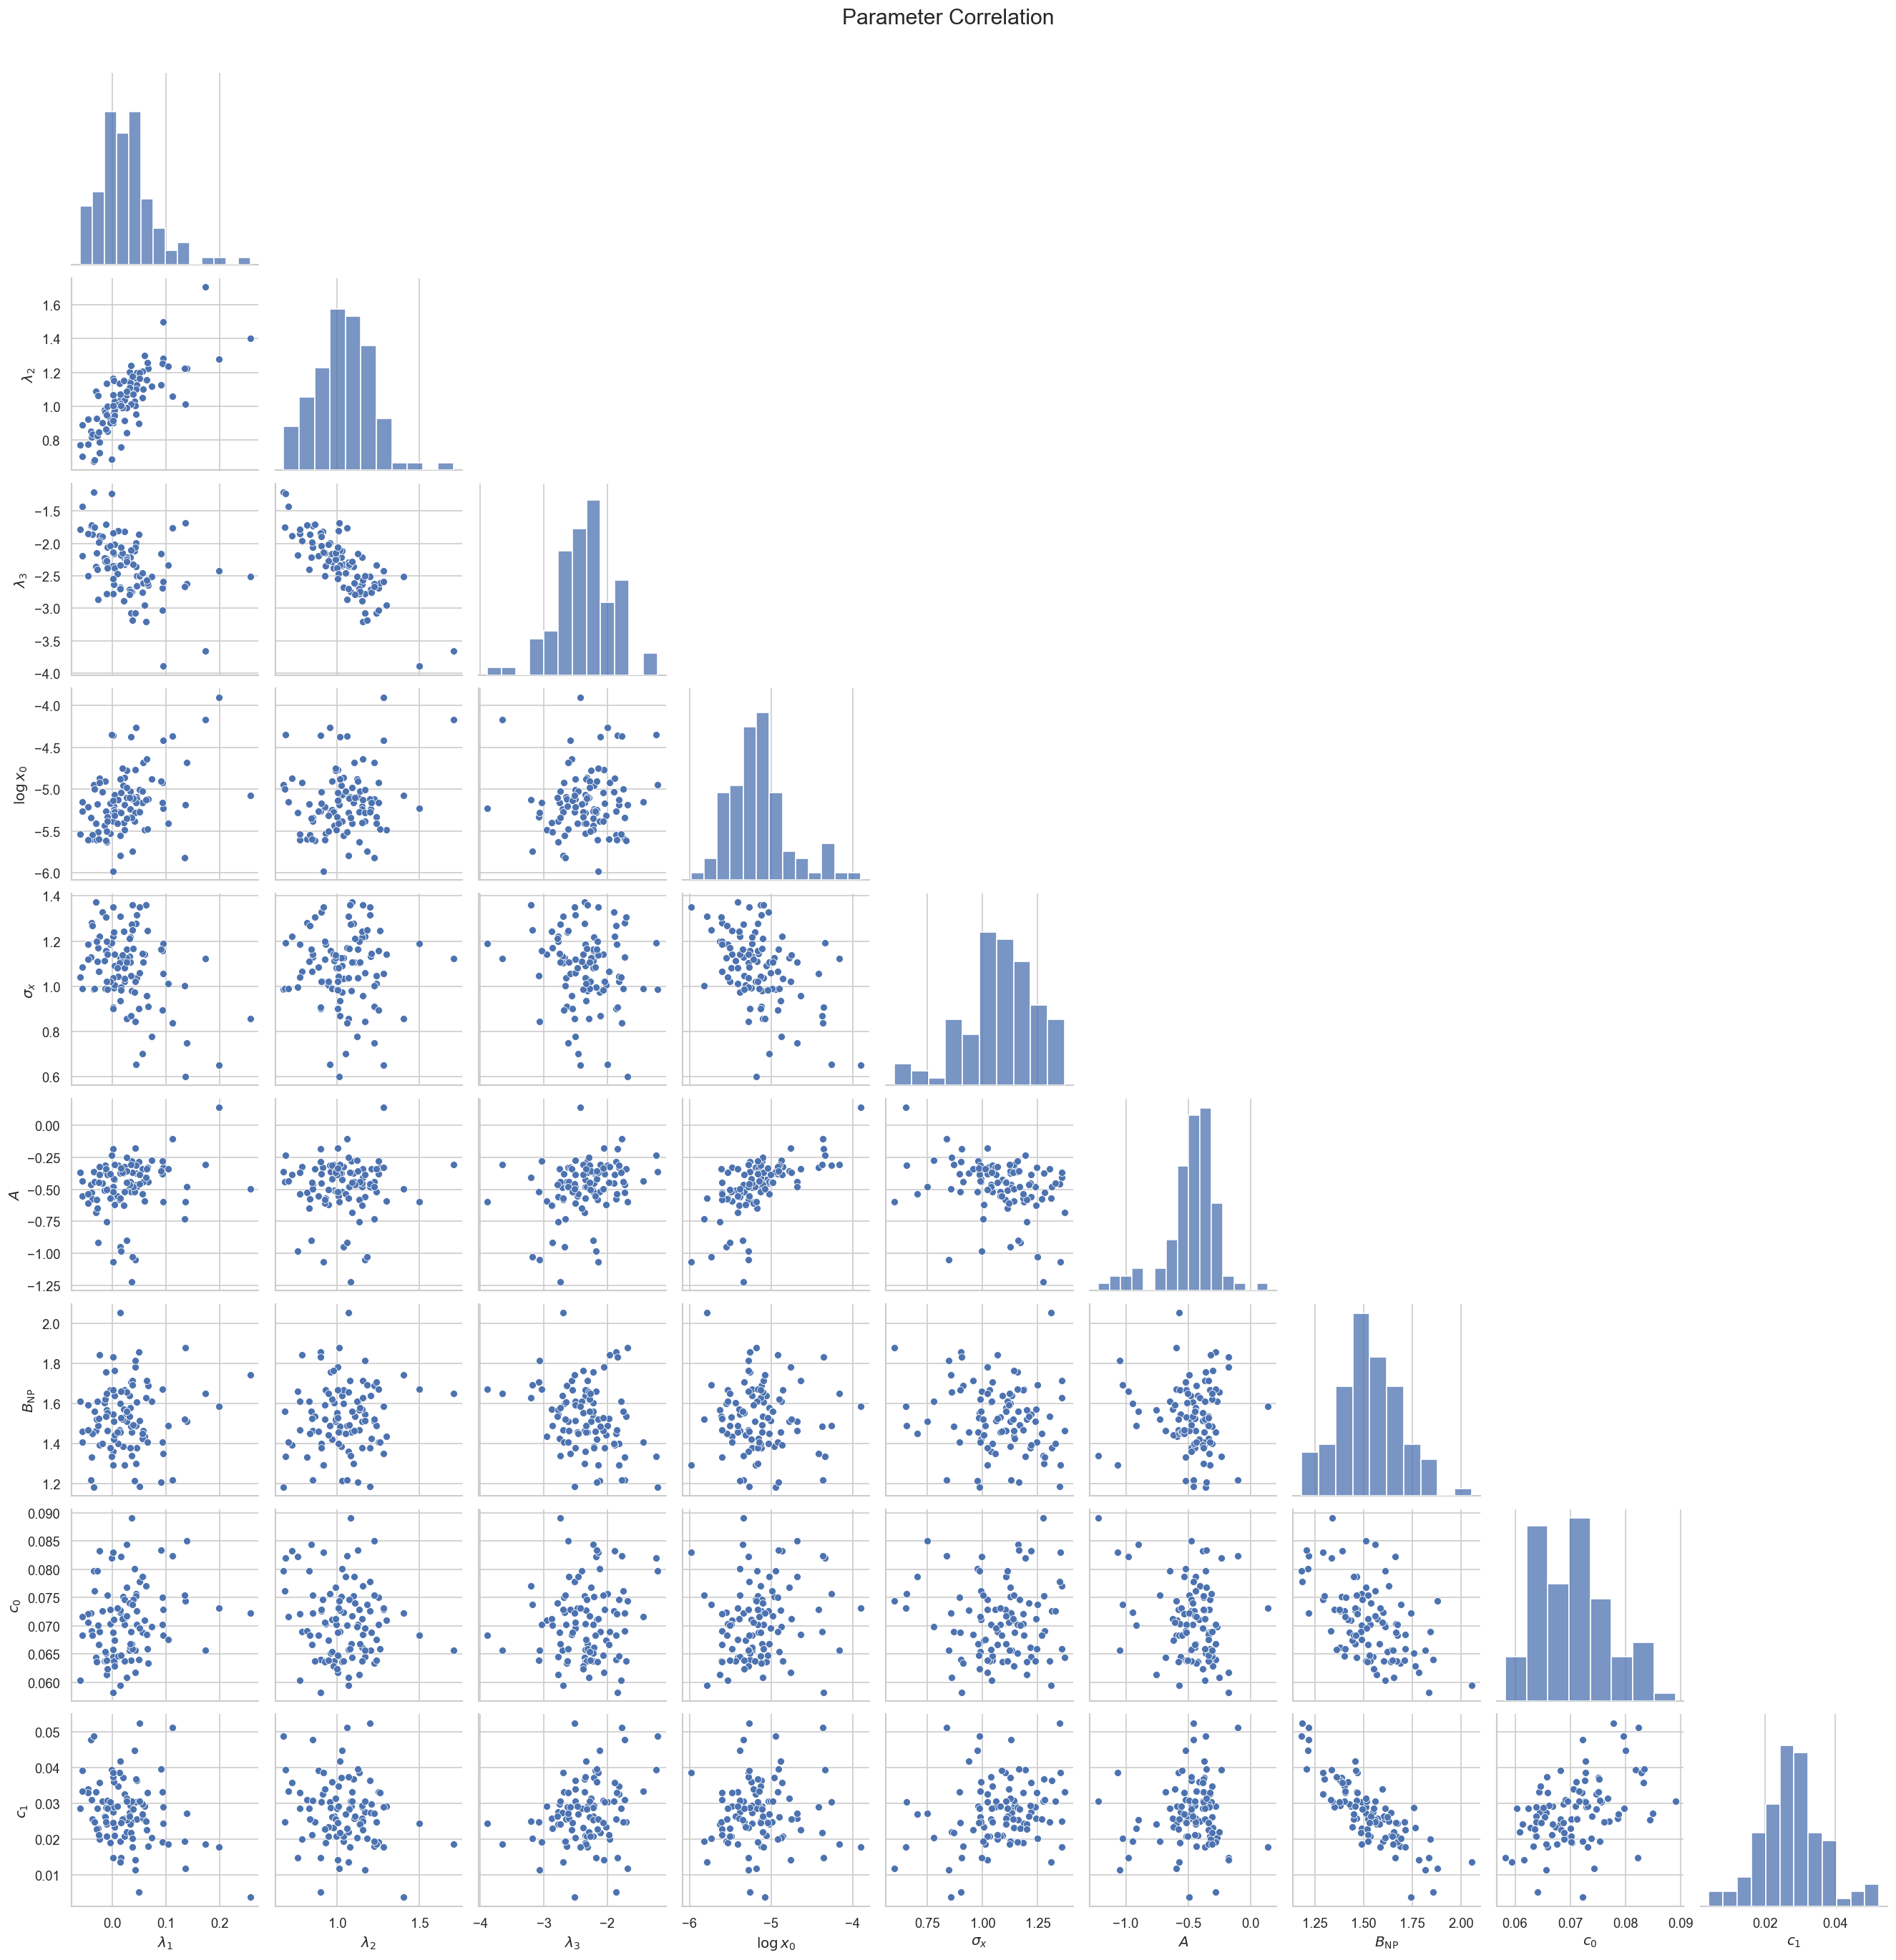

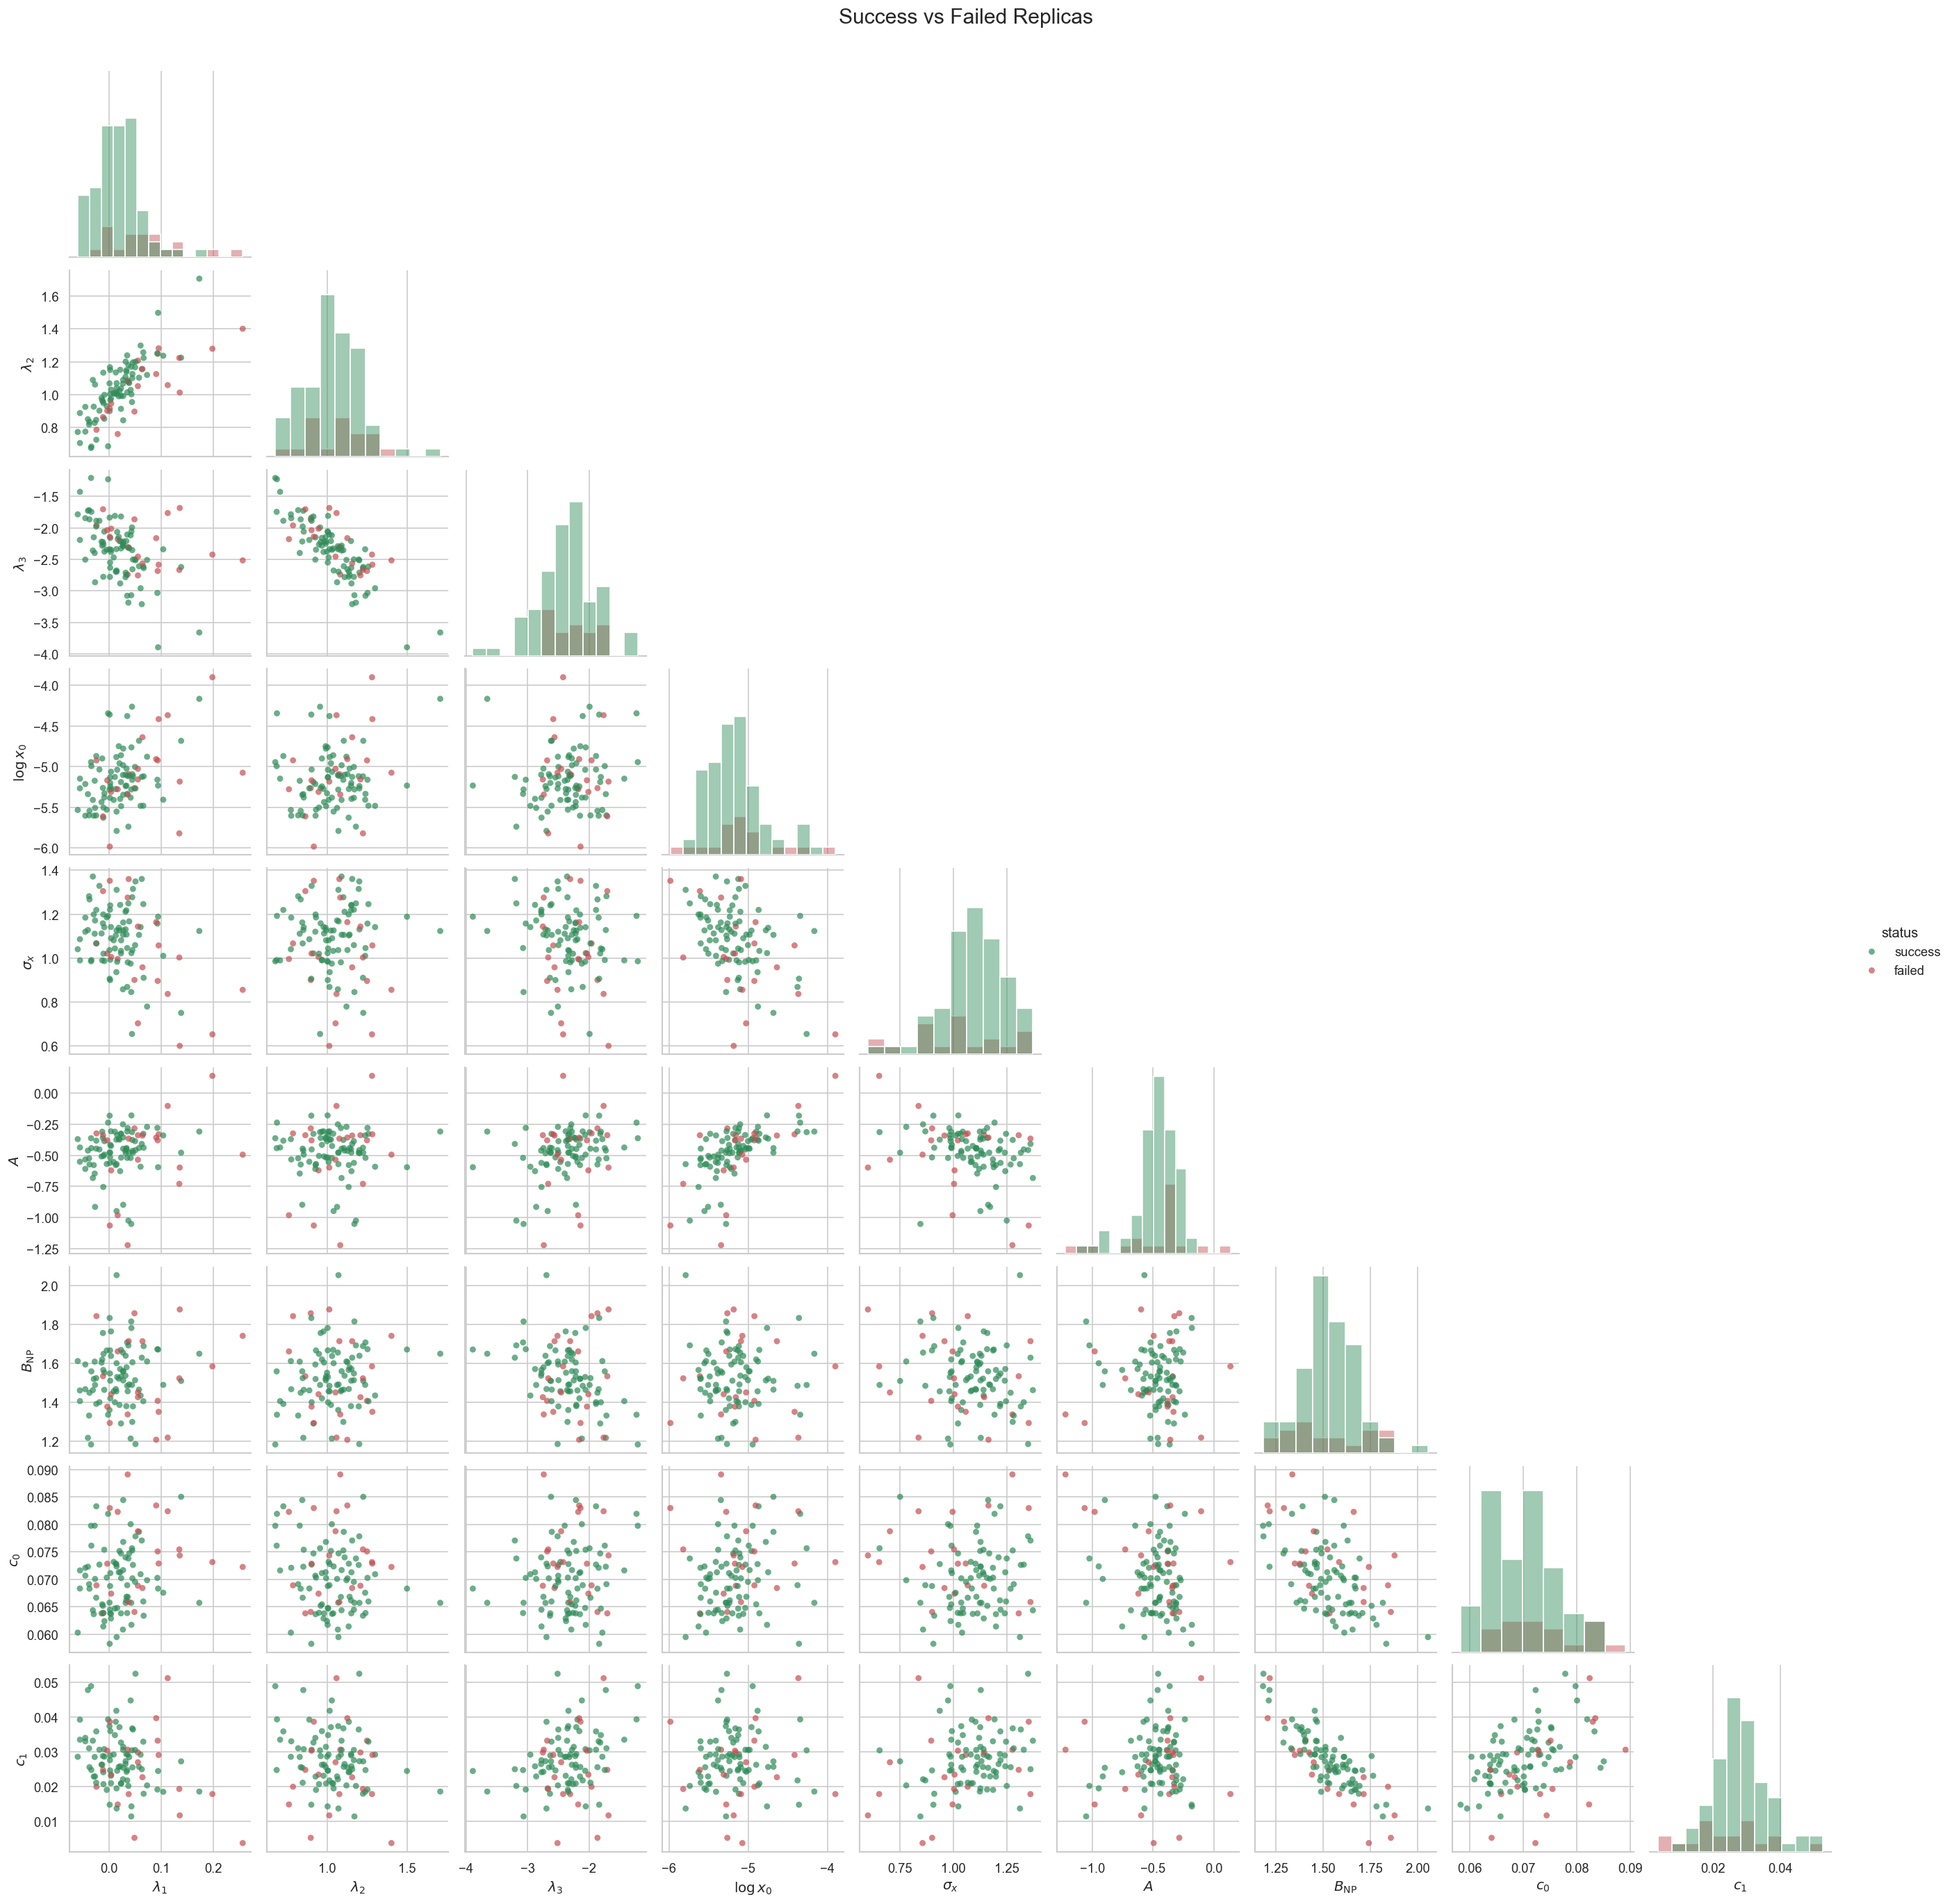

In [7]:
if pairplot_mode == "all":
    pairplot_columns = param_names
else:
    pairplot_columns = [name for i, name in enumerate(param_names) if i not in frozen_set]

plot_df = replica_results_df[pairplot_columns].copy().rename(columns=latex_param_labels)
g = sns.pairplot(plot_df, corner=True, diag_kind="hist")
g.figure.suptitle("Parameter Correlation", y=1.02, fontsize=18)
plt.show()

if show_success_failure_overlay:
    overlay_df = replica_results_all_df[pairplot_columns + ["success"]].copy()
    overlay_df["status"] = overlay_df["success"].map({1: "success", 0: "failed"}).fillna("other")
    overlay_df = overlay_df.drop(columns=["success"]).rename(columns=latex_param_labels)
    palette = {"success": "#2E8B57", "failed": "#C44E52", "other": "#7F7F7F"}
    g = sns.pairplot(
        overlay_df,
        vars=[latex_param_labels[name] for name in pairplot_columns],
        hue="status",
        corner=True,
        diag_kind="hist",
        palette=palette,
        plot_kws={"alpha": 0.7, "s": 28, "edgecolor": "none"},
        diag_kws={"alpha": 0.45, "common_norm": False},
    )
    g.figure.suptitle("Success vs Failed Replicas", y=1.02, fontsize=18)
    plt.show()


,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\log x_0$,$\sigma_x$,$A$,$B_{\rm NP}$,$c_{0}$,$c_{1}$
$\lambda_{1}$,1.000,0.753,-0.429,0.398,-0.384,0.200,0.124,0.201,-0.307
$\lambda_{2}$,0.753,1.000,-0.823,0.158,-0.028,0.031,0.133,-0.145,-0.206
$\lambda_{3}$,-0.429,-0.823,1.000,0.083,-0.160,0.295,-0.301,0.117,0.273
$\log x_0$,0.398,0.158,0.083,1.000,-0.470,0.626,-0.028,0.170,0.038
$\sigma_x$,-0.384,-0.028,-0.160,-0.470,1.000,-0.305,-0.191,-0.017,0.244
$A$,0.200,0.031,0.295,0.626,-0.305,1.000,-0.024,-0.261,0.088
$B_{\rm NP}$,0.124,0.133,-0.301,-0.028,-0.191,-0.024,1.000,-0.522,-0.832
$c_{0}$,0.201,-0.145,0.117,0.170,-0.017,-0.261,-0.522,1.000,0.424
$c_{1}$,-0.307,-0.206,0.273,0.038,0.244,0.088,-0.832,0.424,1.000


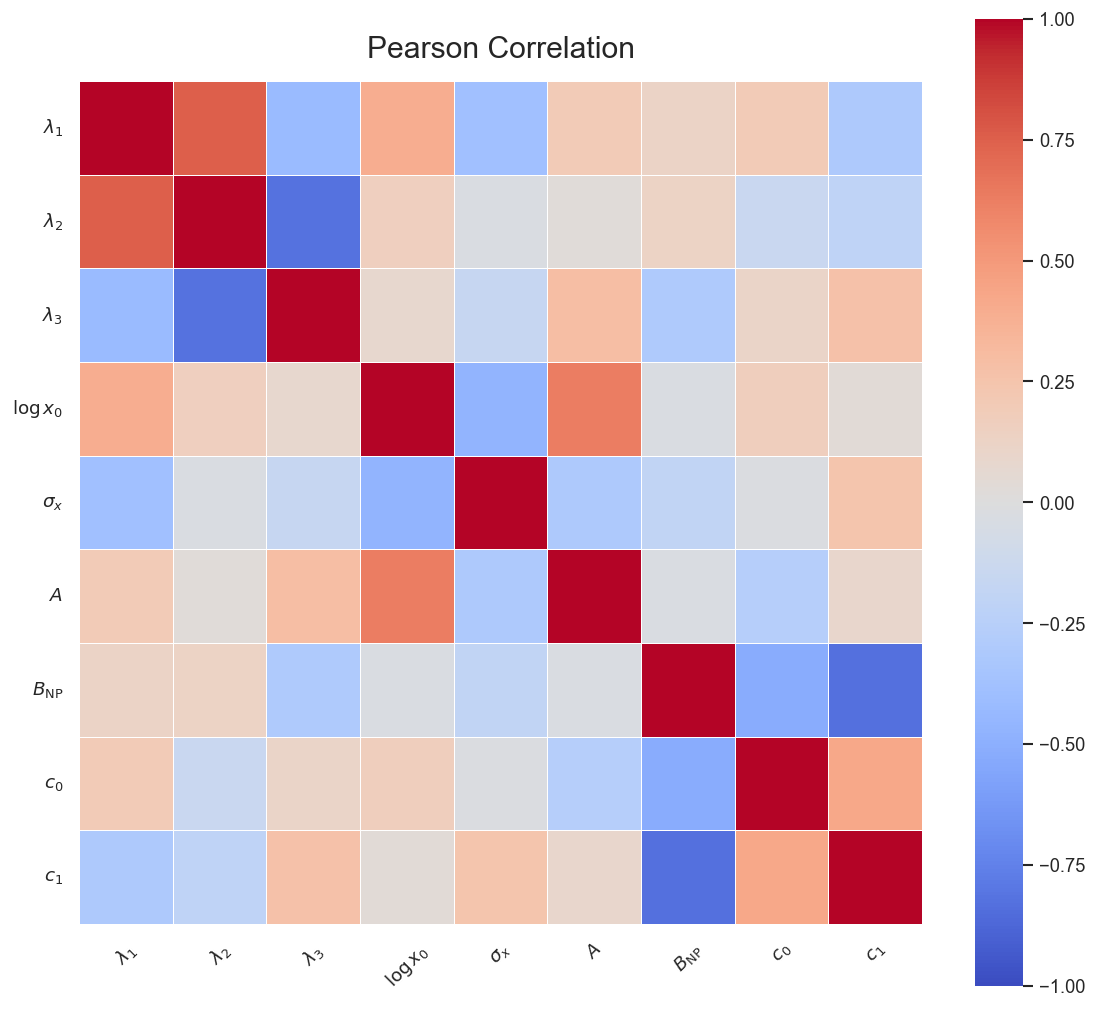

,param_a,param_b,corr,abs_corr
34,$B_{\rm NP}$,$c_{1}$,-0.831805,0.831805
8,$\lambda_{2}$,$\lambda_{3}$,-0.822662,0.822662
0,$\lambda_{1}$,$\lambda_{2}$,0.752882,0.752882
22,$\log x_0$,$A$,0.626363,0.626363
33,$B_{\rm NP}$,$c_{0}$,-0.522415,0.522415
21,$\log x_0$,$\sigma_x$,-0.469677,0.469677
1,$\lambda_{1}$,$\lambda_{3}$,-0.429019,0.429019
35,$c_{0}$,$c_{1}$,0.423799,0.423799
2,$\lambda_{1}$,$\log x_0$,0.397524,0.397524
3,$\lambda_{1}$,$\sigma_x$,-0.383930,0.383930


,quantity,value
0,n_parameters,9.000000
1,max_abs_corr_offdiag,0.831805
2,median_abs_corr_offdiag,0.203119
3,min_eigenvalue,0.008085
4,condition_number,355.240568


In [8]:
if len(pairplot_columns) < 2:
    print("Need at least two parameters to analyze correlations.")
else:
    corr_df = replica_results_df[pairplot_columns].corr()
    corr_df.index = [latex_param_labels[name] for name in corr_df.index]
    corr_df.columns = [latex_param_labels[name] for name in corr_df.columns]
    display(corr_df.round(3))

    fig_w = max(7, 0.8 * len(corr_df.columns) + 2.5)
    fig_h = max(6, 0.8 * len(corr_df.columns) + 1.5)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(
        corr_df,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={},
        ax=ax,
    )
    ax.set_title("Pearson Correlation", fontsize=18, pad=14)
    ax.tick_params(axis="x", labelrotation=45, labelsize=11)
    ax.tick_params(axis="y", labelrotation=0, labelsize=11)
    plt.tight_layout()
    plt.show()

    upper = corr_df.where(np.triu(np.ones(corr_df.shape), k=1).astype(bool))
    corr_pairs = (
        upper.stack()
        .rename("corr")
        .reset_index()
        .rename(columns={"level_0": "param_a", "level_1": "param_b"})
    )
    corr_pairs["abs_corr"] = corr_pairs["corr"].abs()
    corr_pairs = corr_pairs.sort_values(["abs_corr", "param_a", "param_b"], ascending=[False, True, True])
    display(corr_pairs.head(15))

    eigvals = np.linalg.eigvalsh(corr_df.to_numpy())
    corr_summary = pd.DataFrame(
        {
            "quantity": [
                "n_parameters",
                "max_abs_corr_offdiag",
                "median_abs_corr_offdiag",
                "min_eigenvalue",
                "condition_number",
            ],
            "value": [
                len(corr_df.columns),
                corr_pairs["abs_corr"].max() if not corr_pairs.empty else np.nan,
                corr_pairs["abs_corr"].median() if not corr_pairs.empty else np.nan,
                eigvals.min(),
                eigvals.max() / eigvals.min() if eigvals.min() > 0 else np.inf,
            ],
        }
    )
    display(corr_summary)
